# Решение задачи кластеризации методом K-means


=== РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ ===
Распределение объектов по кластерам:
    legs  hair  feathers  eggs  milk  airborne  predator  toothed  backbone  \
2    4.0   1.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
3    4.0   1.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
4    4.0   1.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
5    2.0   1.0       0.0   0.0   1.0       1.0       0.0      1.0       1.0   
6    0.0   0.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
7    2.0   1.0       0.0   0.0   1.0       0.0       0.0      1.0       1.0   
8    2.0   0.0       1.0   1.0   0.0       1.0       1.0      0.0       1.0   
9    2.0   0.0       1.0   1.0   0.0       0.0       0.0      0.0       1.0   
10   2.0   0.0       1.0   1.0   0.0       0.0       0.0      0.0       1.0   
11   0.0   0.0       0.0   1.0   0.0       0.0       1.0      1.0       1.0   
12   4.0   0.0       0.0   1.0   0.0       0.0       1.0    

C:\Users\ivanu\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
C:\Users\ivanu\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


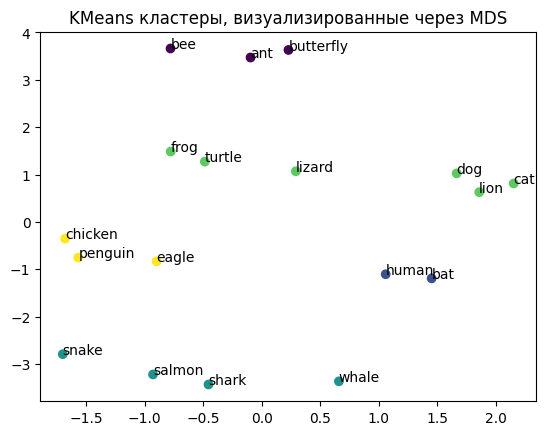

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import MDS

DATA_PATH = 'dataset/zoo.tab'
CLUSTERS = 5

# Получаем датасет из файла zoo.tab. Убираем все строки, где есть нечисловые значения, а также колонку 'animal'
df = pd.read_csv(DATA_PATH, sep='\t')
animals = df['animal'][2:]
features_df = df.drop('animal', axis=1).apply(pd.to_numeric, errors='coerce').dropna()

# Процесс кластеризации (k-means). Количество кластеров выбрал на основе количества видов животных: млекопитающие, рыбы, птицы, насекомые и рептилии
kmeans = KMeans(n_clusters=CLUSTERS, n_init=20)
clusters = kmeans.fit_predict(features_df)
features_df['cluster'] = clusters
features_df['animal'] = animals
print("\n=== РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ ===")
print(f"Распределение объектов по кластерам:\n{features_df}")

# Отрисовываем диаграмму MDS
X_mds = MDS().fit_transform(features_df.drop(columns=['animal', 'cluster'], axis=1))

plt.scatter(X_mds[:,0], X_mds[:,1], c=clusters, cmap='viridis')
plt.title('KMeans кластеры, визуализированные через MDS')

for i, animal in enumerate(animals):
    plt.annotate(animal, (X_mds[i, 0], X_mds[i, 1]))
plt.show()

# Решение задачи кластеризации методом Hierarchical Clustering


=== РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ ===

    legs  hair  feathers  eggs  milk  airborne  predator  toothed  backbone  \
2    4.0   1.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
3    4.0   1.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
4    4.0   1.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
5    2.0   1.0       0.0   0.0   1.0       1.0       0.0      1.0       1.0   
6    0.0   0.0       0.0   0.0   1.0       0.0       1.0      1.0       1.0   
7    2.0   1.0       0.0   0.0   1.0       0.0       0.0      1.0       1.0   
8    2.0   0.0       1.0   1.0   0.0       1.0       1.0      0.0       1.0   
9    2.0   0.0       1.0   1.0   0.0       0.0       0.0      0.0       1.0   
10   2.0   0.0       1.0   1.0   0.0       0.0       0.0      0.0       1.0   
11   0.0   0.0       0.0   1.0   0.0       0.0       1.0      1.0       1.0   
12   4.0   0.0       0.0   1.0   0.0       0.0       1.0      1.0       1.0   
13   4.0   0.0   

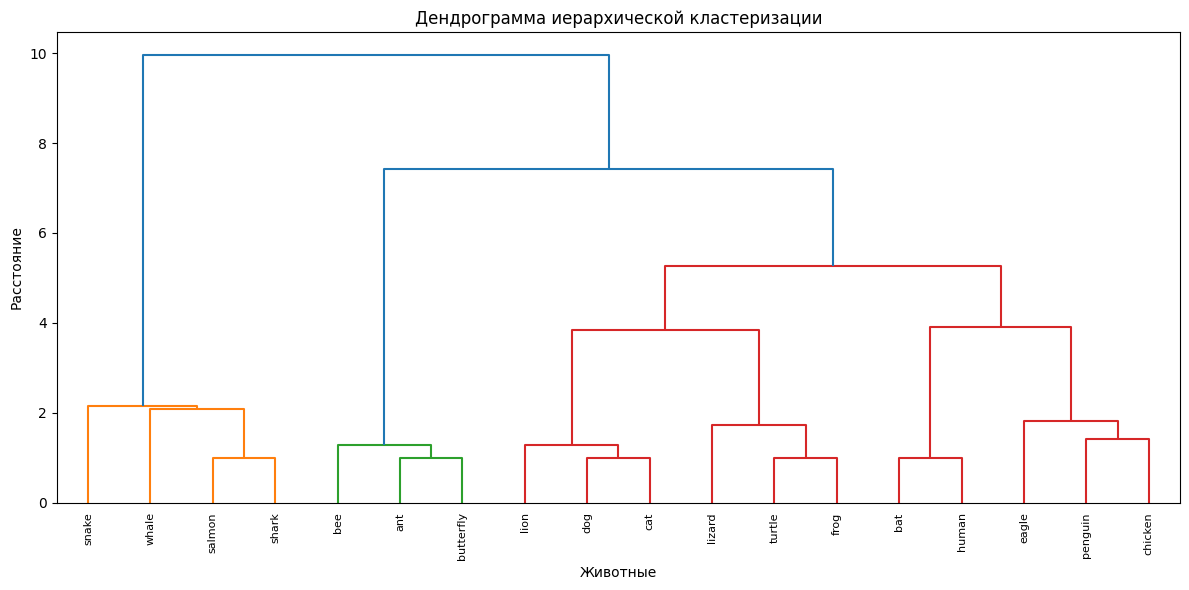

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

DATA_PATH = 'dataset/zoo.tab'
N_CLUSTERS = 5

# Подготовка обучающего dataset
df = pd.read_csv(DATA_PATH, sep='\t')
animals = df.iloc[:, 0].copy()
numeric_rows = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
numeric_rows_index = numeric_rows.dropna().index
numeric_rows = numeric_rows.loc[numeric_rows_index]
animals = animals.loc[numeric_rows_index]

# Иерархическая кластеризация
clustering = AgglomerativeClustering(n_clusters=N_CLUSTERS)
clusters = clustering.fit_predict(numeric_rows)

# Сохраняю метки кластеров в DataFrame для удобства отображения результата обучения в логах
X_clustered = numeric_rows.copy()
X_clustered['cluster'] = clusters
X_clustered['animal'] = animals

print('\n=== РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ ===')
print(f'\n{X_clustered}')

# Построение дендограммы
distance_matrix = pdist(numeric_rows, metric='euclidean')
linkage_matrix = linkage(distance_matrix, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=animals.values, leaf_rotation=90, leaf_font_size=8)
plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Животные')
plt.ylabel('Расстояние')
plt.tight_layout()
plt.show()
